In [1]:
import numpy as np
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Function to fit the model (store training data)
def fit(X_train, y_train):
  return X_train, y_train

In [3]:
def predict(X_train, y_train, X_test, k):
  X_test_expanded = np.expand_dims(X_test, axis=1) #Add a new axis to X_test
  X_train_expanded = np.expand_dims(X_train, axis=0) # Add a new axis to X_train

  # Broadcasting happens here:
  # NumPy matches dimensions by stretching the axis with size 1,
  # creating a shape of (n_test, n_train, n_features)
  differences = X_test_expanded - X_train_expanded

  # Square differences, sum across features (axis=2), and take sqrt to get Euclidean distances
  distances = np.sqrt(np.sum(differences ** 2, axis=2))# (n_test, n_train)

  k_indices = np.argsort(distances, axis=1)[:, :k]   # Sort distances for each test point and get indices of the k smallest

  # Store predicted labels for each test point
  y_pred=[]
  for neighbors in k_indices:
    labels = y_train[neighbors]
    prediction = np.bincount(labels).argmax() #majority vote
    y_pred.append(prediction)

  return np.array(y_pred)


In [4]:
def score(y_true, y_pred):
  return np.mean(y_true == y_pred)

In [5]:
#Loading Dataset
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
#Customized KNN
X_train, y_train = fit(X_train, y_train)
start_custom = time.time()
y_pred_custom = predict(X_train, y_train, X_test, k=3)
acc_custom = score(y_test, y_pred_custom)
time_custom = time.time() - start_custom

In [7]:
print(f"Custom KNN Accuracy: {acc_custom*100:.2f}%")
print(f"Custom KNN Time: {time_custom:.6f} sec")

Custom KNN Accuracy: 100.00%
Custom KNN Time: 0.001390 sec


In [8]:
#sklearn KNN
start_sklearn = time.time()
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
acc_sklearn = knn.score(X_test, y_test)
time_sklearn = time.time() - start_sklearn

In [9]:
print(f"Sklearn KNN Accuracy: {acc_sklearn*100:.2f}%")
print(f"Sklearn KNN Time: {time_sklearn:.6f} sec")

Sklearn KNN Accuracy: 100.00%
Sklearn KNN Time: 0.006104 sec


This shows that for simple models like KNN, vectorized code can outperform library implementations on small datasets.

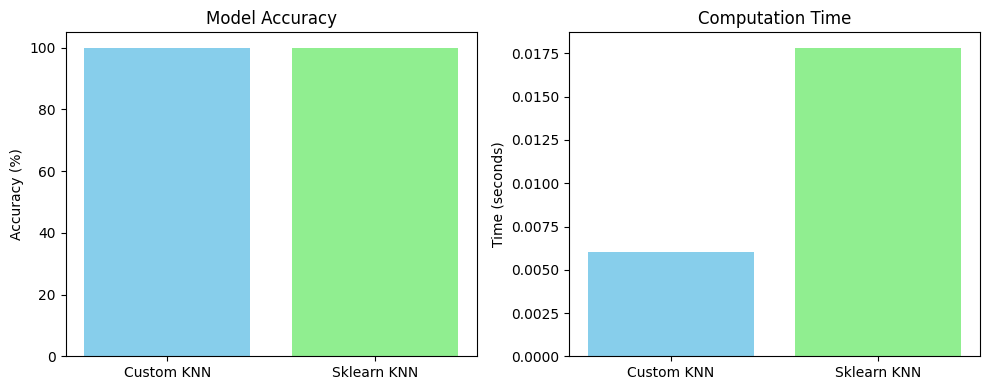

In [10]:
import matplotlib.pyplot as plt

# Data
models = ['Custom KNN', 'Sklearn KNN']
accuracy = [100.00, 100.00]  # Accuracy in %
time_taken = [0.006036, 0.017830]  # Time in seconds

# Create figure
plt.figure(figsize=(10, 4))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.bar(models, accuracy, color=['skyblue', 'lightgreen'])
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.title('Model Accuracy')

# Time subplot
plt.subplot(1, 2, 2)
plt.bar(models, time_taken, color=['skyblue', 'lightgreen'])
plt.ylabel('Time (seconds)')
plt.title('Computation Time')

# Adjust layout
plt.tight_layout()
plt.show()